# Representative Propellers — Edge Cases

**Author:** Héctor Fernández Pinacho · IDEAL Lab, ETH Zürich

Finds 5 special configs from the 100 representative propellers:
- Most solid overall (max of inner+mid solidity)
- Most inner-solidity dominated
- Thinnest wall (min absolute blade thickness)
- Most average in performance (T, T/W, FOM, Pshaft, eff_aero)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
from pathlib import Path
from scipy.interpolate import CubicSpline

BASE_DIR    = Path('.')
PREVIEW_DIR = BASE_DIR / 'previews'
PLOT_DIR    = BASE_DIR / 'plots'
PLOT_DIR.mkdir(exist_ok=True)

rep = pd.read_csv(BASE_DIR / 'csv' / 'representative_propellers.csv')
print(f'Loaded {len(rep)} representative propellers')

# ── Theme ──
BG      = '#0F1117'; BG_CARD = '#1A1D27'; BG_TITLE = '#252545'
TEXT    = '#CDD6F4'; DIM     = '#7B8099'; GRID_C   = '#2A2D3A'
C_BLUE  = '#89B4FA'; C_TEAL  = '#94E2D5'; C_PEACH  = '#FAB387'
C_MAUVE = '#CBA6F7'; C_GREEN = '#A6E3A1'; C_RED    = '#F38BA8'
C_OVER  = '#585B70'; C_YEL   = '#F9E2AF'
STATION_COLORS = [C_BLUE, C_OVER, C_TEAL, C_PEACH]

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG_CARD,
    'axes.edgecolor': GRID_C, 'axes.labelcolor': DIM,
    'axes.titlecolor': TEXT, 'text.color': TEXT,
    'xtick.color': DIM, 'ytick.color': DIM,
    'axes.grid': True, 'grid.color': GRID_C, 'grid.linewidth': 0.5,
    'legend.facecolor': BG_CARD, 'legend.edgecolor': GRID_C,
})

R_INNER_MM = 4.5
R_HUB_MM   = 8.25
V_AXIAL    = 1.0


Loaded 100 representative propellers


In [2]:
# ── Select the 5 special configs ──────────────────────────────────────────

# 1. Most solid overall: highest average of inner + mid solidity
rep['sol_combined'] = rep['inner_solidity'] + rep['mid_solidity']
idx_most_solid   = rep['sol_combined'].idxmax()

# 2. Most inner-solidity dominated: highest inner_solidity
idx_most_inner   = rep['inner_solidity'].idxmax()

# 3. Thinnest wall: lowest min absolute blade thickness
idx_thinnest     = rep['min_blade_abs_thickness_mm'].idxmin()

# 4. Most average performance: closest to mean in normalised perf space
PERF_COLS = ['T', 'T_over_W_static', 'FOM', 'Pshaft', 'eff_aero']
X     = rep[PERF_COLS].dropna()
X_n   = (X - X.min()) / (X.max() - X.min())
dists = np.sqrt(((X_n - X_n.mean())**2).sum(axis=1))
idx_avg = dists.idxmin()

# Store as row dicts so scalar access is unambiguous
def get_row(idx): return rep.loc[idx].squeeze() if hasattr(rep.loc[idx],'squeeze') else rep.loc[idx]

special = [
    (idx_most_solid,  'Most Solid',            C_MAUVE),
    (idx_most_inner,  'Highest Inner Solidity', C_PEACH),
    (idx_thinnest,    'Thinnest Wall',          C_RED),
    (idx_avg,         'Most Average Perf.',     C_GREEN),
]

hdr = f"{'Label':<26} {'config_id':>10} {'inner_sol':>10} {'mid_sol':>10} {'min_wall_mm':>12} {'T':>7} {'FOM':>7} {'T/W':>7}"
print(hdr)
print('-'*90)
for idx, label, _ in special:
    r = rep.loc[idx]
    print(f'{label:<26} {int(r["config_id"]):>10} {float(r["inner_solidity"]):>10.3f} '
          f'{float(r["mid_solidity"]):>10.3f} {float(r["min_blade_abs_thickness_mm"]):>12.2f} '
          f'{float(r["T"]):>7.3f} {float(r["FOM"]):>7.4f} {float(r["T_over_W_static"]):>7.2f}')


Label                       config_id  inner_sol    mid_sol  min_wall_mm       T     FOM     T/W
------------------------------------------------------------------------------------------
Most Solid                        427      0.694      0.648         1.14   0.115  0.1940    1.02
Highest Inner Solidity            427      0.694      0.648         1.14   0.115  0.1940    1.02
Thinnest Wall                     168      0.482      0.497         1.00   0.154  0.4669    1.51
Most Average Perf.               2116      0.617      0.502         1.44   0.220  0.4098    1.62


In [3]:
# ── Helper functions ───────────────────────────────────────────────────────

def naca4_coords(code, n=120):
    s = str(code).zfill(4)
    m=int(s[0])/100; p=int(s[1])/10; t=int(s[2:])/100
    x=(1-np.cos(np.linspace(0,np.pi,n)))/2
    yt=5*t*(0.2969*x**0.5-0.1260*x-0.3516*x**2+0.2843*x**3-0.1015*x**4)
    if m==0 or p==0: yc=np.zeros_like(x); dyc=np.zeros_like(x)
    else:
        yc =np.where(x<p,m/p**2*(2*p*x-x**2),m/(1-p)**2*((1-2*p)+2*p*x-x**2))
        dyc=np.where(x<p,2*m/p**2*(p-x),      2*m/(1-p)**2*(p-x))
    theta=np.arctan(dyc)
    return x-yt*np.sin(theta),yc+yt*np.cos(theta),x+yt*np.sin(theta),yc-yt*np.cos(theta)

def draw_foil(ax, code, pitch, chord_scale, color, alpha=0.40, lw=1.4):
    xu,yu,xl,yl=naca4_coords(code)
    xu*=chord_scale; yu*=chord_scale; xl*=chord_scale; yl*=chord_scale
    a=np.radians(-pitch); ca,sa=np.cos(a),np.sin(a)
    xur=xu*ca-yu*sa; yur=xu*sa+yu*ca
    xlr=xl*ca-yl*sa; ylr=xl*sa+yl*ca
    cx=(np.concatenate([xur,xlr]).max()+np.concatenate([xur,xlr]).min())/2
    cy=(np.concatenate([yur,ylr]).max()+np.concatenate([yur,ylr]).min())/2
    fx=np.concatenate([xur,xlr[::-1]])-cx; fy=np.concatenate([yur,ylr[::-1]])-cy
    ax.fill(fx,fy,color=color,alpha=alpha,linewidth=0)
    ax.plot(fx,fy,color=color,linewidth=lw)

def interp_at_r(row, r_t, ci, cm, co):
    r_i=R_INNER_MM; r_m=row['mid radial pos']*row['radius']; r_o=row['radius']
    xs=np.array([r_i,r_m,r_o]); ys=np.array([row[ci],row[cm],row[co]],dtype=float)
    if r_t<=r_i+0.01: return float(ys[0])
    return float(CubicSpline(xs,ys)(np.clip(r_t,r_i,r_o)))

def aoa_deg(pitch, r_mm, rpm, v_ax=V_AXIAL):
    omega=rpm*2*np.pi/60; v_tan=omega*(r_mm/1000)
    return pitch - np.degrees(np.arctan2(v_ax, v_tan))

def card_ax(fig, gs_spec, bg=BG_CARD):
    ax=fig.add_subplot(gs_spec); ax.set_facecolor(bg)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_C); sp.set_linewidth(0.7)
    return ax


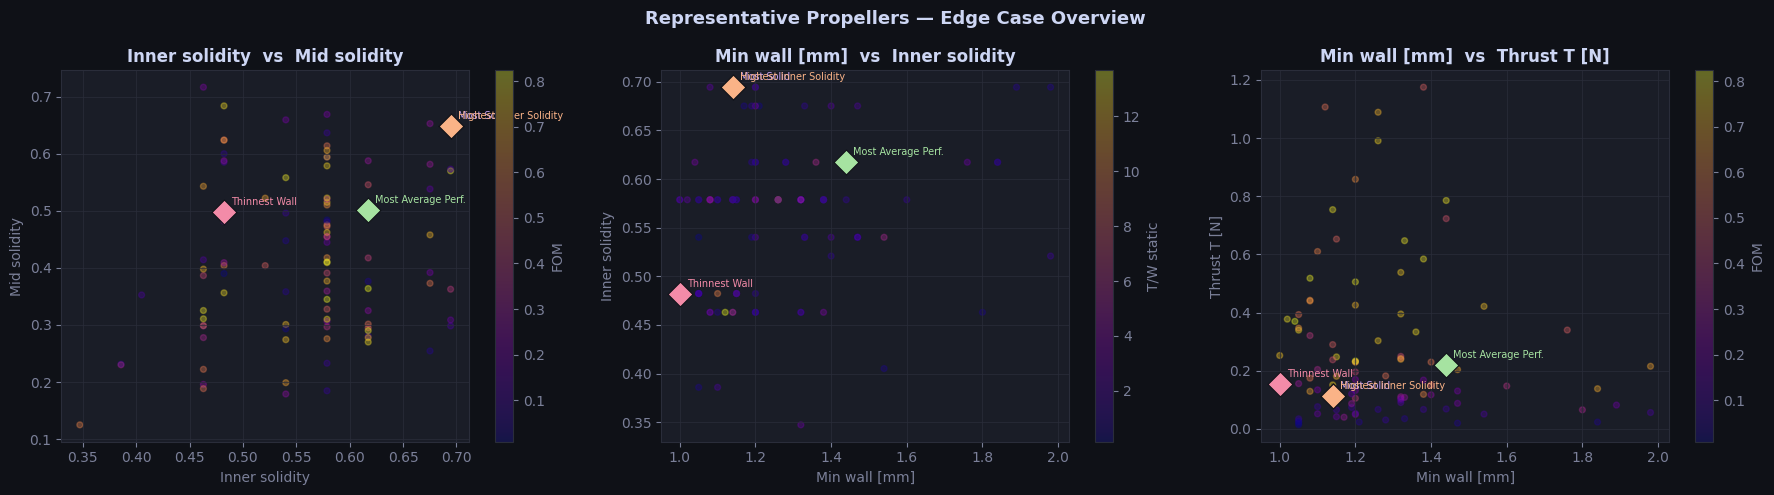

In [4]:
# ── Overview scatter: inner_solidity vs min_wall, coloured by FOM ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Representative Propellers — Edge Case Overview', fontsize=13, fontweight='bold')

panels = [
    ('inner_solidity',          'mid_solidity',              'FOM',           'Inner solidity',      'Mid solidity',         'FOM'),
    ('min_blade_abs_thickness_mm','inner_solidity',           'T_over_W_static','Min wall [mm]',      'Inner solidity',       'T/W static'),
    ('min_blade_abs_thickness_mm','T',                        'FOM',           'Min wall [mm]',       'Thrust T [N]',         'FOM'),
]
for ax,(xc,yc,cc,xl,yl,cl) in zip(axes,panels):
    sc=ax.scatter(rep[xc],rep[yc],c=rep[cc],cmap='plasma',alpha=0.35,s=18)
    cb=plt.colorbar(sc,ax=ax); cb.set_label(cl,color=DIM)
    for idx,label,col in special:
        r=rep.loc[idx]
        ax.scatter([r[xc]],[r[yc]],color=col,s=160,zorder=6,
                   marker='D',edgecolors=BG,linewidths=0.8)
        ax.annotate(label,(r[xc],r[yc]),fontsize=7,color=col,
                    xytext=(5,5),textcoords='offset points')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl}  vs  {yl}', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR/'rep_edge_overview.png',dpi=140,bbox_inches='tight',facecolor=BG)
plt.show()


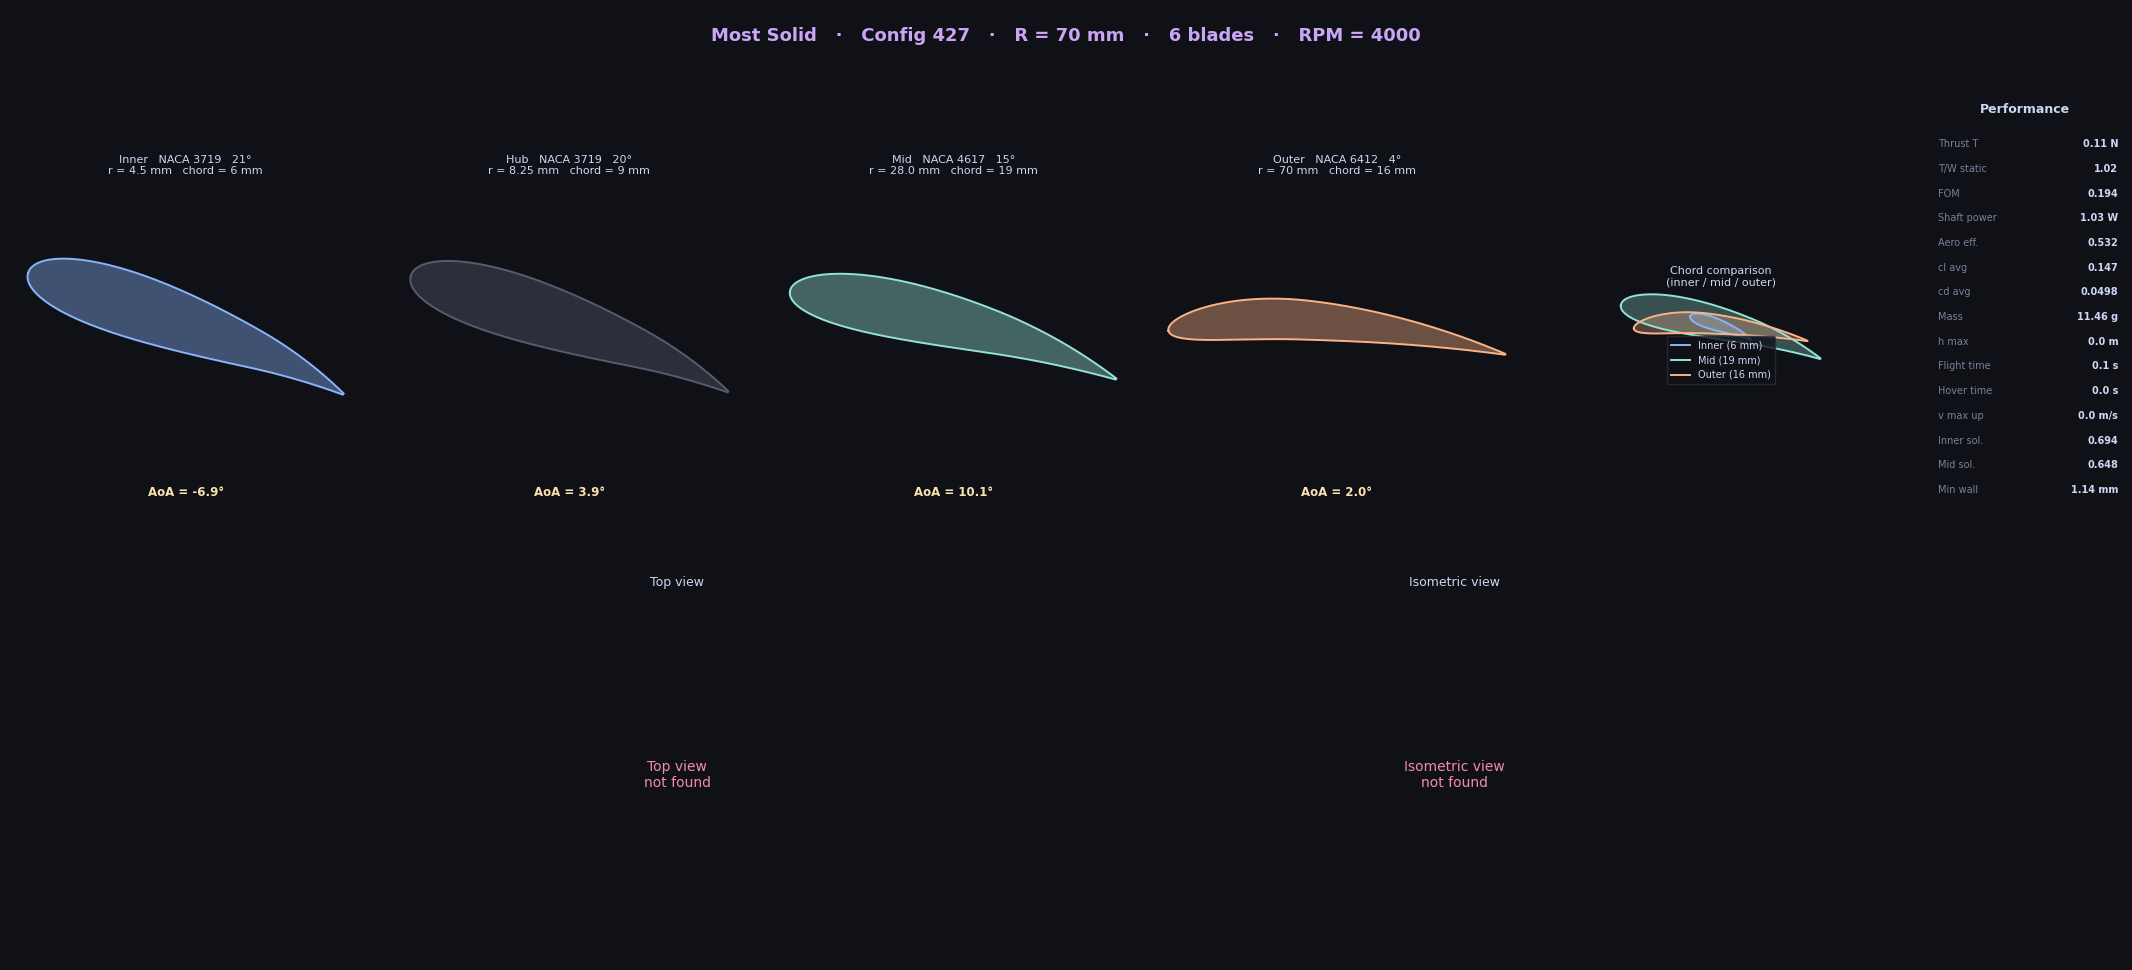

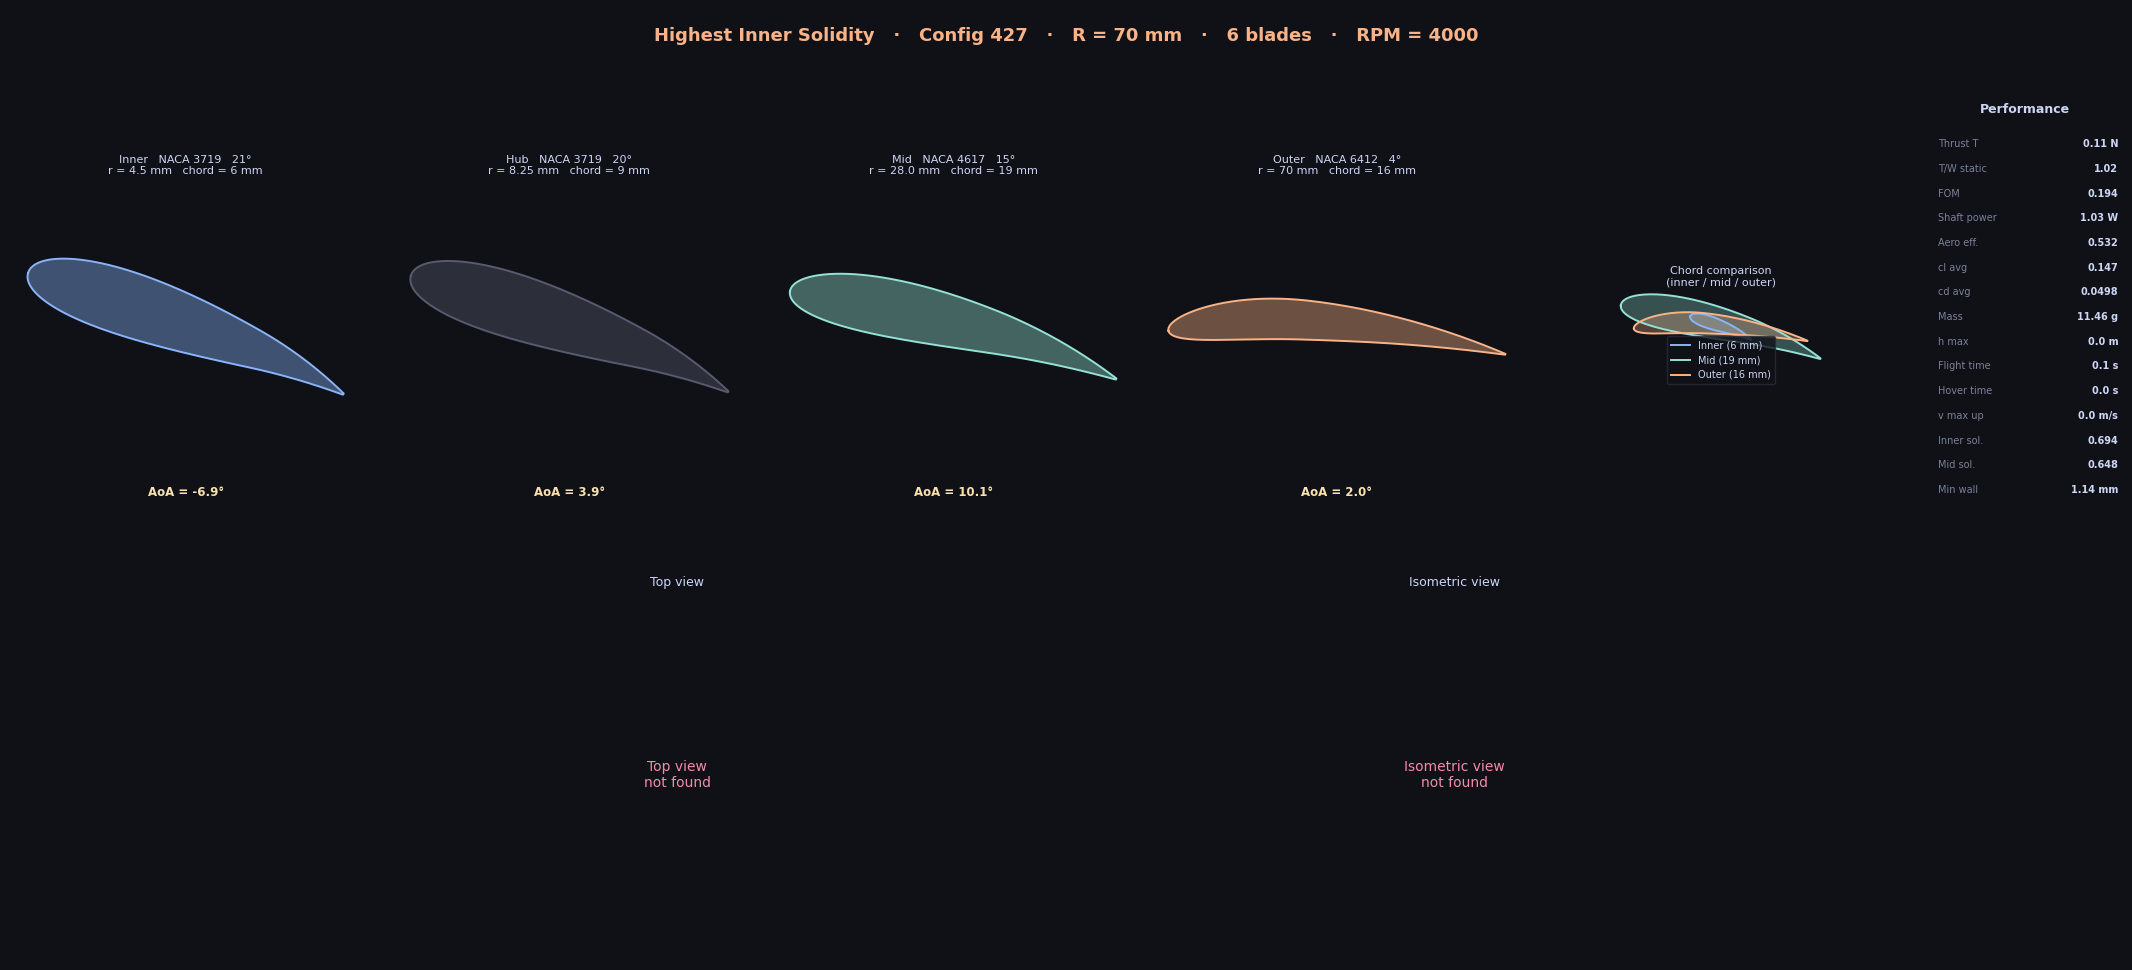

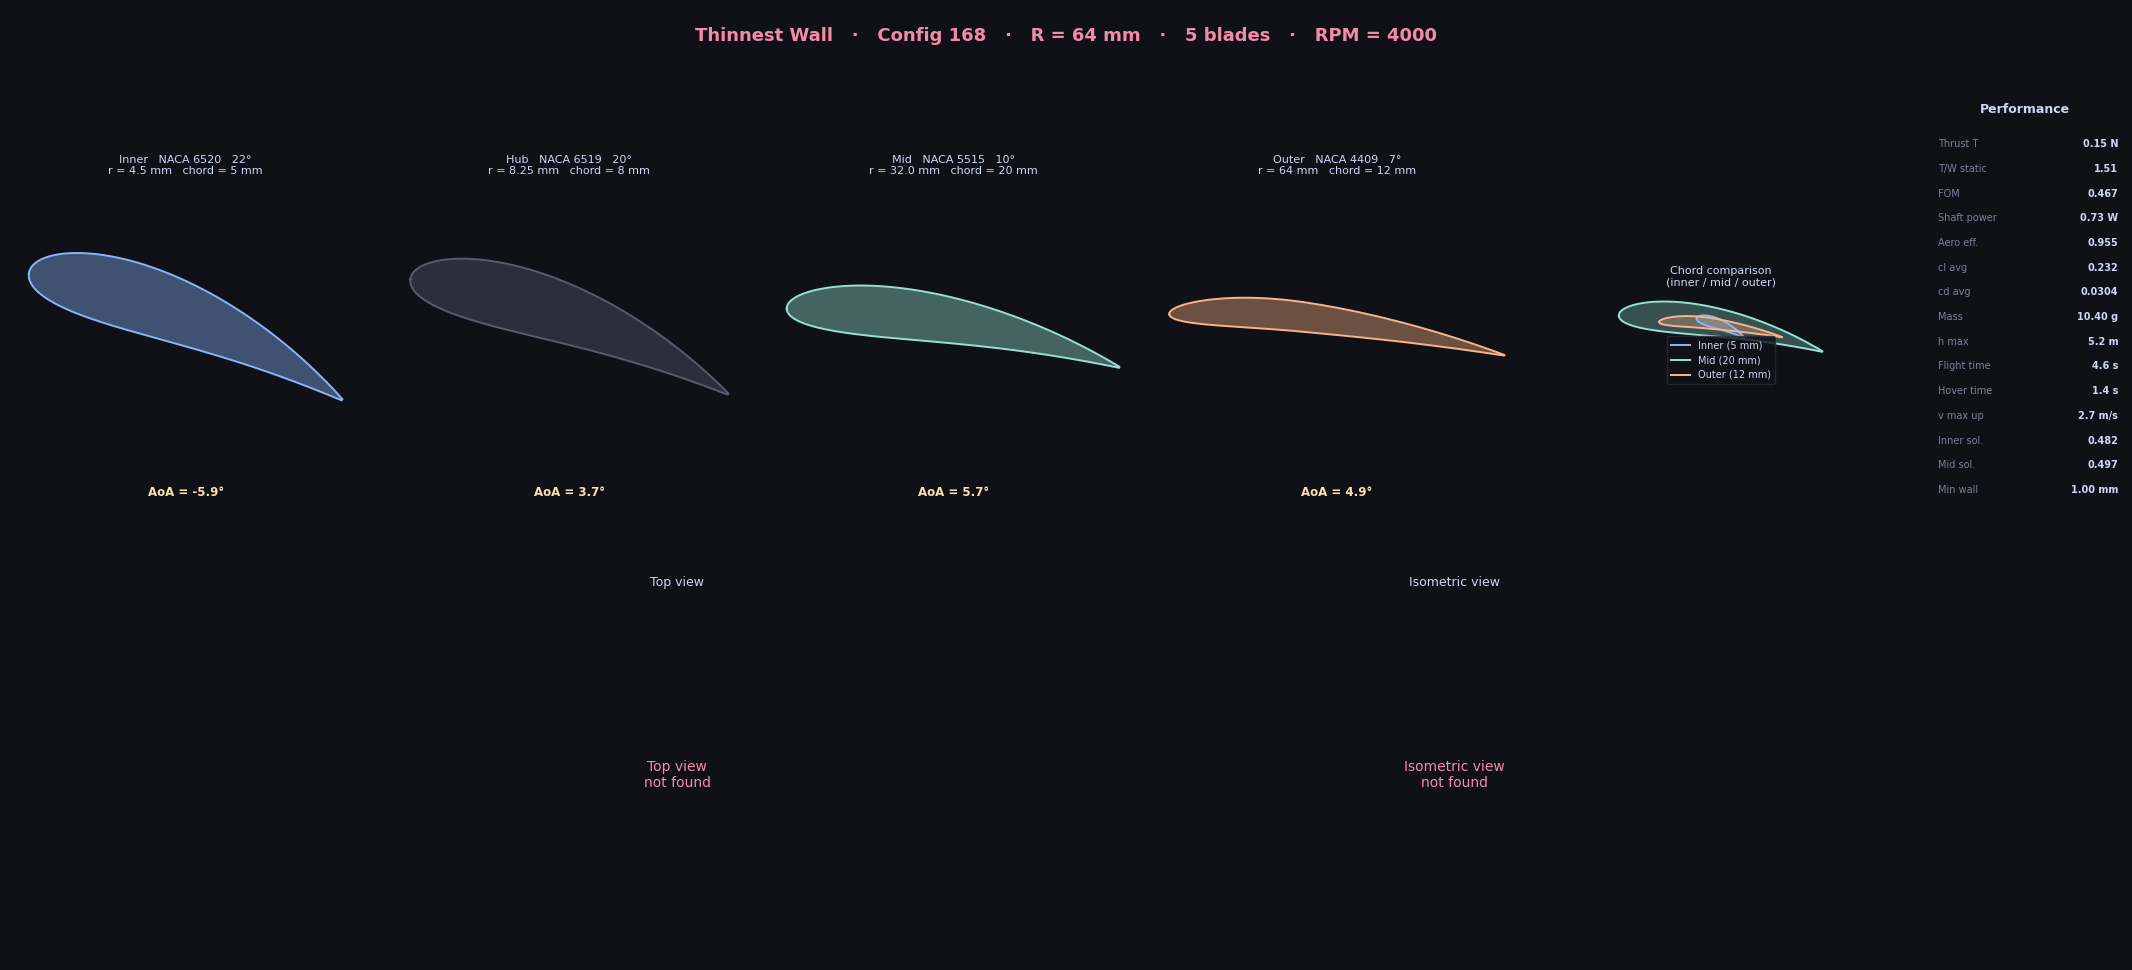

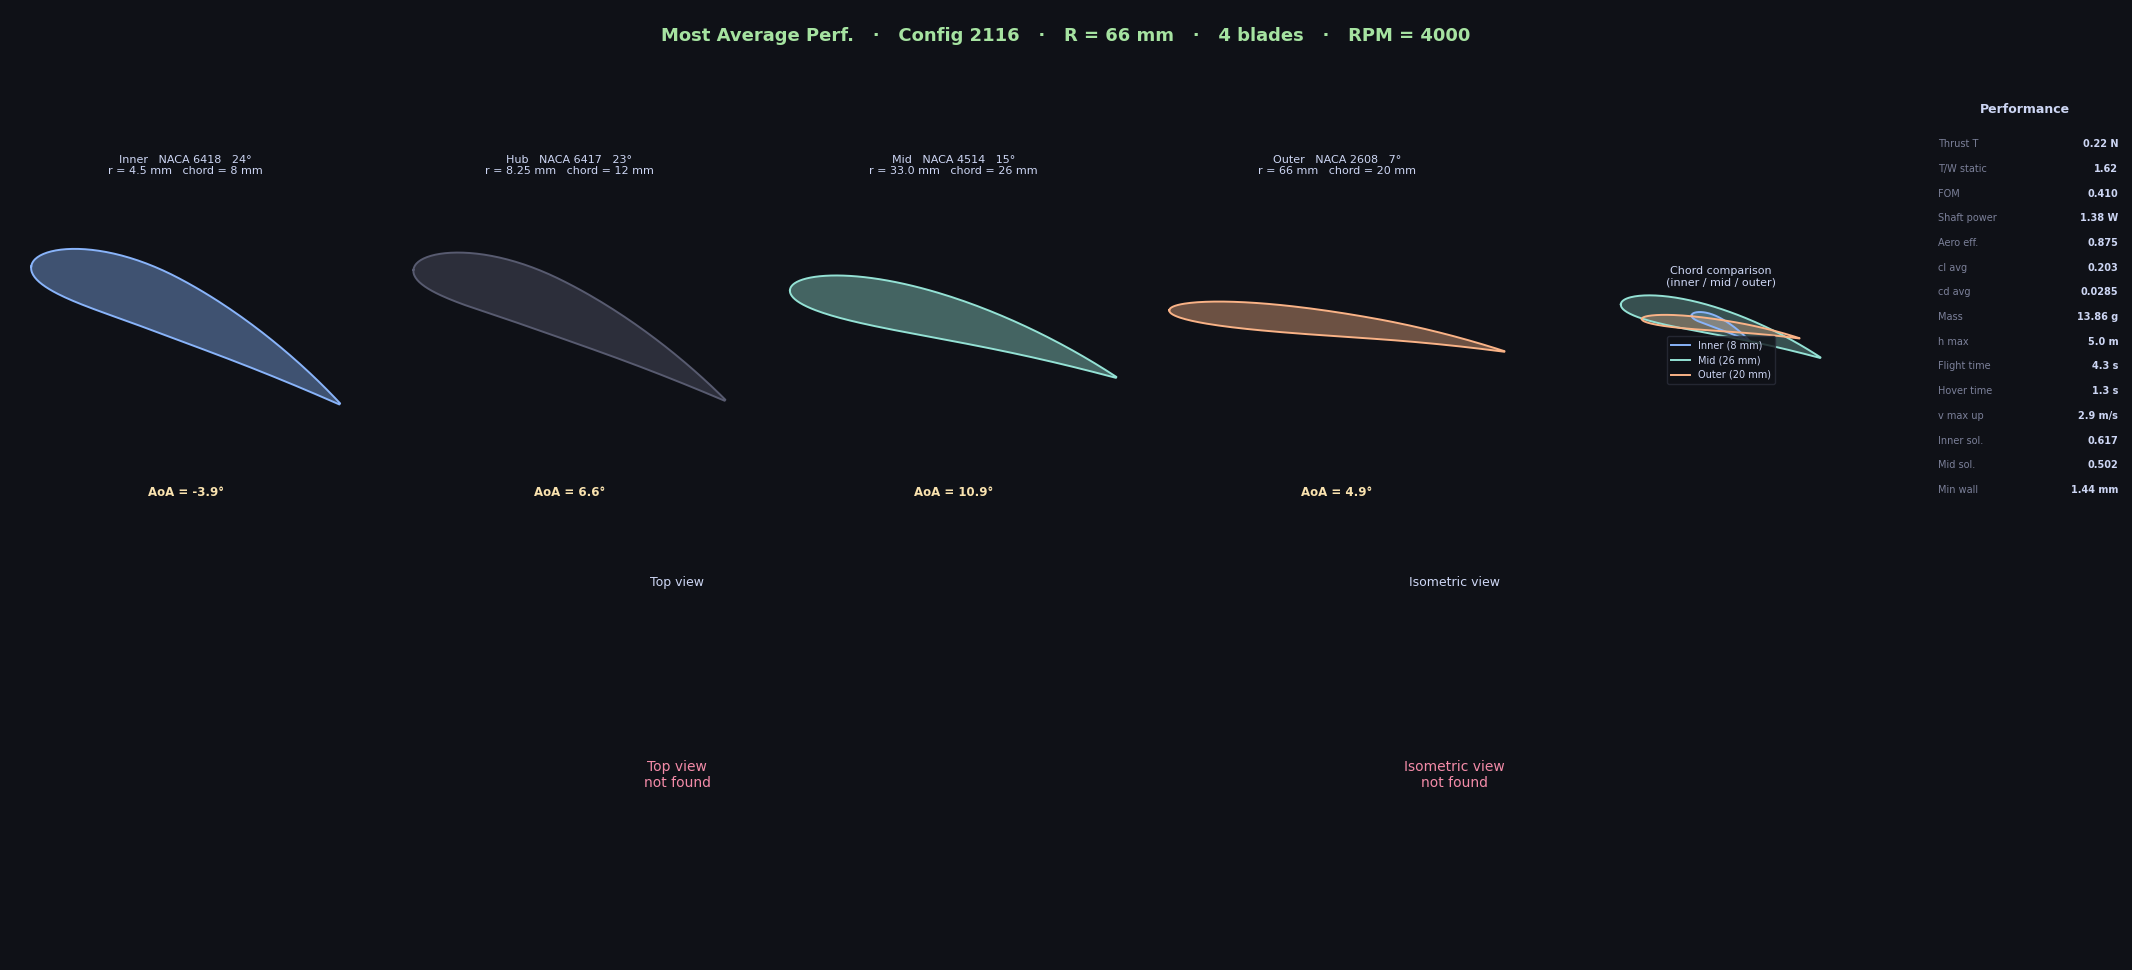

Done.


In [5]:
# ── Per-config full card (same layout as notebook 11) ─────────────────────
PAD_EQ = 0.52; PAD_OV = 0.30

for idx, case_label, case_color in special:
    prop = rep.loc[idx]
    cfg_id   = int(prop['config_id'])
    n_blades = int(prop['blade count'])
    radius   = float(prop['radius'])
    rpm_val  = float(prop.get('rpm', 4000))

    chords = {'inner':float(prop['inner chord']),'mid':float(prop['mid chord']),'outer':float(prop['outer chord'])}
    chords['hub'] = interp_at_r(prop,R_HUB_MM,'inner chord','mid chord','outer chord')
    angles = {'inner':float(prop['inner angle']),'mid':float(prop['mid angle']),'outer':float(prop['outer angle'])}
    angles['hub'] = interp_at_r(prop,R_HUB_MM,'inner angle','mid angle','outer angle')
    nacas  = {k: str(int(prop[f'naca_{k}'])).zfill(4) if pd.notna(prop.get(f'naca_{k}')) else '0012'
              for k in ['inner','hub','mid','outer']}
    max_chord = max(chords.values())
    r_lbl  = {'inner':f'{R_INNER_MM:.1f}','hub':f'{R_HUB_MM:.2f}',
              'mid':f'{prop["mid radial pos"]*radius:.1f}','outer':f'{radius:.0f}'}
    r_mm_v = {'inner':R_INNER_MM,'hub':R_HUB_MM,
              'mid':prop['mid radial pos']*radius,'outer':radius}
    aoa_v  = {k: aoa_deg(angles[k],r_mm_v[k],rpm_val) for k in ['inner','hub','mid','outer']}

    def fmt(v,unit='',d=2):
        try: return f'{float(v):.{d}f}{unit}'
        except: return 'N/A'
    perf_lines = [
        ('Thrust T',     fmt(prop.get('T'),' N')),
        ('T/W static',   fmt(prop.get('T_over_W_static'),'',2)),
        ('FOM',          fmt(prop.get('FOM'),'',3)),
        ('Shaft power',  fmt(prop.get('Pshaft'),' W')),
        ('Aero eff.',    fmt(prop.get('eff_aero'),'',3)),
        ('cl avg',       fmt(prop.get('cl_avg'),'',3)),
        ('cd avg',       fmt(prop.get('cd_avg'),'',4)),
        ('Mass',         fmt(prop['m_total_kg']*1000,' g')),
        ('h max',        fmt(prop.get('h_max_m'),' m',1)),
        ('Flight time',  fmt(prop.get('flight_time_s'),' s',1)),
        ('Hover time',   fmt(prop.get('hover_time_s'),' s',1)),
        ('v max up',     fmt(prop.get('v_max_up_m_s'),' m/s',1)),
        ('Inner sol.',   fmt(prop.get('inner_solidity'),'',3)),
        ('Mid sol.',     fmt(prop.get('mid_solidity'),'',3)),
        ('Min wall',     fmt(prop.get('min_blade_abs_thickness_mm'),' mm',2)),
    ]

    fig = plt.figure(figsize=(22,10), facecolor=BG)
    outer = gridspec.GridSpec(3,1,figure=fig,
                              height_ratios=[0.06,0.52,0.42],
                              hspace=0.12,left=0.02,right=0.98,top=0.97,bottom=0.02)

    # Title banner
    tax=fig.add_subplot(outer[0]); tax.set_facecolor(BG_TITLE); tax.axis('off')
    tax.text(0.5,0.5,
             f'{case_label}   ·   Config {cfg_id}   ·   R = {int(radius)} mm   ·   {n_blades} blades   ·   RPM = {int(rpm_val)}',
             transform=tax.transAxes,ha='center',va='center',
             fontsize=13,fontweight='bold',color=case_color)

    # Middle row: 5 NACA cards + sidebar
    mid=gridspec.GridSpecFromSubplotSpec(1,6,subplot_spec=outer[1],
                                         width_ratios=[1,1,1,1,1,0.55],wspace=0.10)

    for col_i,(key,label) in enumerate(zip(['inner','hub','mid','outer'],
                                            ['Inner','Hub','Mid','Outer'])):
        ax=card_ax(fig,mid[col_i])
        draw_foil(ax,nacas[key],angles[key],1.0,STATION_COLORS[col_i])
        ax.set_xlim(-PAD_EQ,PAD_EQ); ax.set_ylim(-PAD_EQ,PAD_EQ)
        ax.set_aspect('equal'); ax.axis('off')
        ax.text(0.5,0.99,
                f'{label}   NACA {nacas[key]}   {angles[key]:.0f}°\nr = {r_lbl[key]} mm   chord = {chords[key]:.0f} mm',
                transform=ax.transAxes,ha='center',va='top',fontsize=8,color=TEXT)
        ax.text(0.5,0.01,f'AoA = {aoa_v[key]:.1f}°',
                transform=ax.transAxes,ha='center',va='bottom',
                fontsize=8.5,color=C_YEL,fontweight='bold')

    # Chord overlay
    ax5=card_ax(fig,mid[4])
    for key,col in [('inner',STATION_COLORS[0]),('mid',STATION_COLORS[2]),('outer',STATION_COLORS[3])]:
        cn=chords[key]/max_chord
        xu,yu,xl,yl=naca4_coords(nacas[key])
        xu*=cn; yu*=cn; xl*=cn; yl*=cn
        a=np.radians(-angles[key]); ca,sa=np.cos(a),np.sin(a)
        xur=xu*ca-yu*sa; yur=xu*sa+yu*ca
        xlr=xl*ca-yl*sa; ylr=xl*sa+yl*ca
        cx=(np.concatenate([xur,xlr]).max()+np.concatenate([xur,xlr]).min())/2
        cy=(np.concatenate([yur,ylr]).max()+np.concatenate([yur,ylr]).min())/2
        fx=np.concatenate([xur,xlr[::-1]])-cx; fy=np.concatenate([yur,ylr[::-1]])-cy
        ax5.fill(fx,fy,color=col,alpha=0.30,linewidth=0)
        ax5.plot(fx,fy,color=col,linewidth=1.4,label=f'{key.capitalize()} ({chords[key]:.0f} mm)')
    ax5.set_xlim(-PAD_OV-0.55,PAD_OV+0.55); ax5.set_ylim(-PAD_OV,PAD_OV)
    ax5.set_aspect('equal'); ax5.axis('off')
    ax5.text(0.5,0.99,'Chord comparison\n(inner / mid / outer)',
             transform=ax5.transAxes,ha='center',va='top',fontsize=8,color=TEXT)
    ax5.legend(loc='lower center',fontsize=7,ncol=1,
               facecolor=BG,edgecolor=GRID_C,labelcolor=TEXT,framealpha=0.8)

    # Sidebar
    sid=fig.add_subplot(mid[5]); sid.set_facecolor('#0E1628'); sid.axis('off')
    for sp in sid.spines.values(): sp.set_edgecolor(GRID_C); sp.set_linewidth(0.7)
    sid.text(0.5,0.99,'Performance',transform=sid.transAxes,
             ha='center',va='top',fontsize=9,fontweight='bold',color=TEXT)
    for i,(lbl,val) in enumerate(perf_lines):
        y=0.91-i*0.054
        sid.text(0.05,y,lbl,transform=sid.transAxes,ha='left',va='top',fontsize=7,color=DIM)
        sid.text(0.98,y,val,transform=sid.transAxes,ha='right',va='top',fontsize=7,color=TEXT,fontweight='bold')

    # Bottom: renders
    ss=outer[2].get_position(fig)
    bot=gridspec.GridSpec(1,2,figure=fig,wspace=0.02,
                          left=0.15,right=0.85,bottom=ss.y0,top=ss.y1)
    for gs_col,(img_path,title) in enumerate([
            (PREVIEW_DIR/f'top_{cfg_id}.png','Top view'),
            (PREVIEW_DIR/f'iso_{cfg_id}.png','Isometric view')]):
        ax_img=fig.add_subplot(bot[gs_col]); ax_img.set_facecolor('#0D0D1A'); ax_img.axis('off')
        if img_path.exists():
            ax_img.imshow(mpimg.imread(str(img_path)))
        else:
            ax_img.text(0.5,0.5,f'{title}\nnot found',transform=ax_img.transAxes,
                        ha='center',va='center',fontsize=10,color=C_RED)
        ax_img.set_title(title,fontsize=9,color=TEXT,pad=3)

    plt.savefig(PLOT_DIR/f'rep_edge_{case_label.lower().replace(" ","_")}_{cfg_id}.png',
                dpi=130,bbox_inches='tight',facecolor=BG)
    plt.show(); plt.close(fig)

print('Done.')
